In [1]:
import pandas as pd

df = pd.read_csv("co2_mm_mlo.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month  decimal date  average  deseasonalized  ndays  sdev  \
date                                                                          
1958-03-01  1958      3     1958.2027   315.71          314.44     -1 -9.99   
1958-04-01  1958      4     1958.2877   317.45          315.16     -1 -9.99   
1958-05-01  1958      5     1958.3699   317.51          314.69     -1 -9.99   
1958-06-01  1958      6     1958.4548   317.27          315.15     -1 -9.99   
1958-07-01  1958      7     1958.5370   315.87          315.20     -1 -9.99   

             unc  
date              
1958-03-01 -0.99  
1958-04-01 -0.99  
1958-05-01 -0.99  
1958-06-01 -0.99  
1958-07-01 -0.99  


In [2]:
# Number of months to hold out
holdout_months = 18

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1958-03-01 00:00:00 to 2025-01-01 00:00:00
Number of observations: 803

Holdout data:
2025-02-01 00:00:00 to 2026-07-01 00:00:00
Number of observations: 18


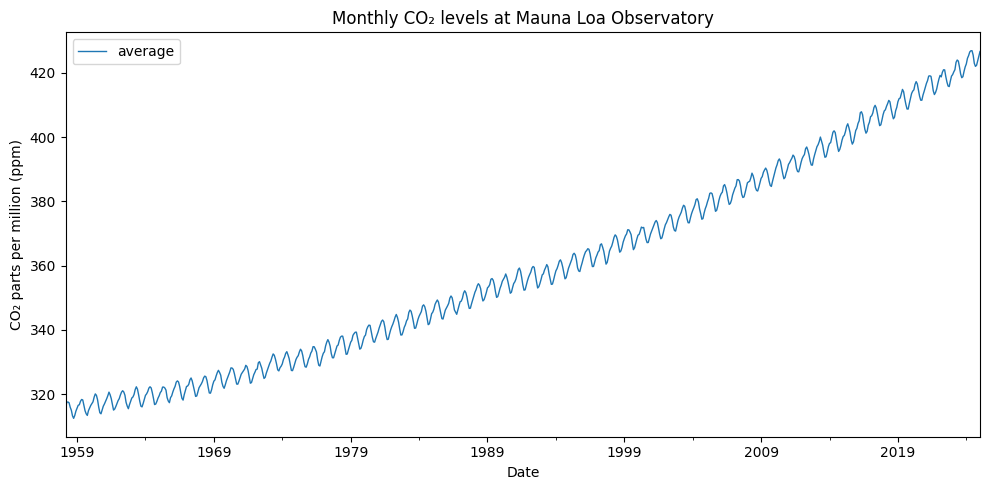

In [3]:
# Step 1: PLot the raw Series
import matplotlib.pyplot as plt

train.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly CO₂ levels at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO₂ parts per million (ppm)")
plt.tight_layout()
plt.show()

### Raw Series Analysis: Monthly CO₂ at Mauna Loa
- The plot of monthly CO₂ levels at Mauna Loa Observatory shows two dominant features: a **strong long‑term upward trend** and a clear **seasonal cycle**. 
- These visual patterns justify applying time‑series methods that can capture both long‑term trend behavior and seasonal structure such as trend‑seasonal decomposition or SARIMA modeling.
- The plot indicates that CO₂ levels have increased from roughly 315 ppm in the late 1950s to over 420 ppm in recent years, with no visible periods of sustained decline.
- These characteristics indicate that the series is **non‑stationary**, meaning its statistical properties (mean, variance, autocorrelation) change over time. Stationarity is a key requirement for many time‑series models, including ARIMA and SARIMA.
- To assess stationarity, two complementary tests are applied:
    - **Augmented Dickey–Fuller (ADF) Test**
        - **Null hypothesis:** the series has a unit root (non‑stationary).
        - Expected outcome for CO₂: **fail to reject the null**.
    - **KPSS Test**
        - **Null hypothesis:** the series is stationary around a deterministic trend.
        - Expected outcome for CO₂: **reject the null**.

In [4]:
# Step 2: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(train["average"])

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(train["average"], regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : 6.2359
p-value       : 1.0000
Lags Used     : 21
Observations  : 781

Critical Values:
   1%: -3.4388
   5%: -2.8652
   10%: -2.5687


KPSS Test
----------------
KPSS Statistic : 4.2576
p-value        : 0.0100
Lags Used      : 18

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_1212/4093660534.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(train["average"], regression='c', nlags='auto')


### Stationarity Tests

To assess stationarity, both the Augmented Dickey–Fuller (ADF) and KPSS tests were applied.

#### **1. Augmented Dickey–Fuller (ADF) Test**

- Null hypothesis: the series has a unit root (non‑stationary).  
- Test statistic: `ADF = 5.9076`  
- p‑value: `p = 1.0000`  
- Critical values:  
  - 1%: `-3.4386`  
  - 5%: `-2.8652`  
  - 10%: `-2.5687`

Since the test statistic is far above all critical values, we **fail to reject the null hypothesis**.  
**Interpretation:** The CO₂ series is non‑stationary.

#### **2. KPSS Test**

- Null hypothesis: the series is stationary around a deterministic trend.  
- Test statistic: `KPSS = 4.3471`  
- p‑value: `p = 0.0100` (actual p‑value even smaller; outside lookup table range)  
- Critical values:  
  - 1%: `0.7390`  
  - 2.5%: `0.5740`  
  - 5%: `0.4630`  
  - 10%: `0.3470`

The KPSS statistic exceeds all critical values, so we **reject the null hypothesis**.  
**Interpretation:** The series is non‑stationary due to trend and level behavior.

---

### Combined Interpretation

As expected both tests agree:

**The raw CO₂ series is strongly non‑stationary, driven by both trend and seasonality.**

---

### Next Steps

To prepare the series for modeling:

- Apply **seasonal differencing** (`lag = 12`) to remove annual seasonality.  
- Apply **regular differencing** (`lag = 1`) to remove the long‑term trend.  
- Re‑run ADF and KPSS on the differenced series to confirm stationarity.  
- Proceed with SARIMA or decomposition‑based modeling to capture both seasonal and non‑seasonal dynamics.



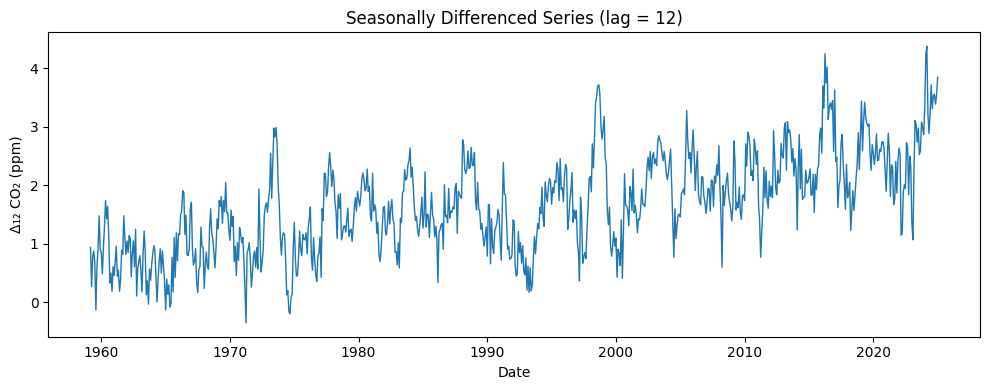

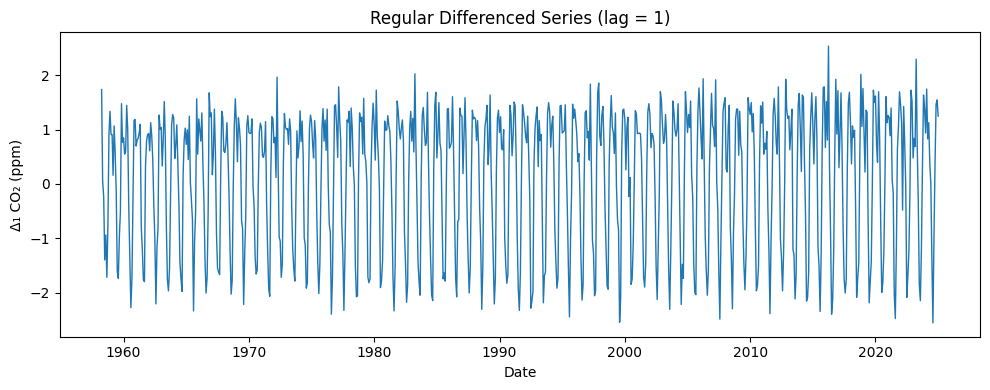

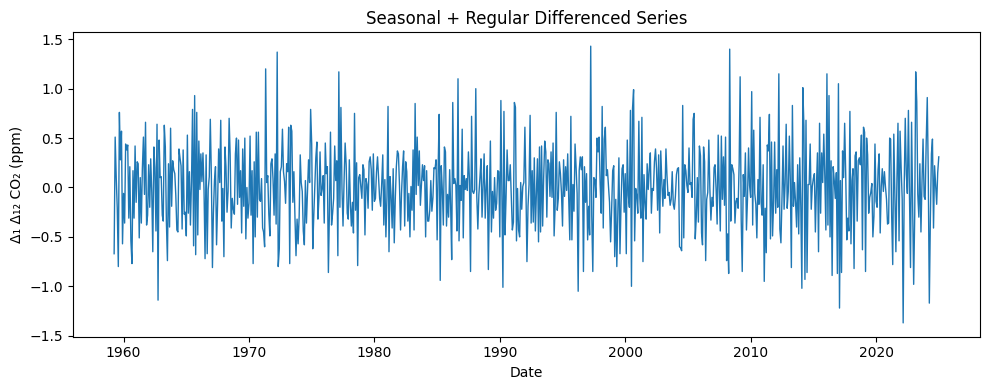

In [6]:
import matplotlib.pyplot as plt

# --- Seasonal differencing (lag 12) ---
train["diff_seasonal"] = train["average"].diff(12)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_seasonal"], linewidth=1)
plt.title("Seasonally Differenced Series (lag = 12)")
plt.xlabel("Date")
plt.ylabel("Δ₁₂ CO₂ (ppm)")
plt.tight_layout()
plt.show()

# --- Regular differencing (lag 1) ---
train["diff_regular"] = train["average"].diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_regular"], linewidth=1)
plt.title("Regular Differenced Series (lag = 1)")
plt.xlabel("Date")
plt.ylabel("Δ₁ CO₂ (ppm)")
plt.tight_layout()
plt.show()

# --- Combined differencing: seasonal + regular ---
train["diff_both"] = train["average"].diff(12).diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_both"], linewidth=1)
plt.title("Seasonal + Regular Differenced Series")
plt.xlabel("Date")
plt.ylabel("Δ₁ Δ₁₂ CO₂ (ppm)")
plt.tight_layout()
plt.show()


### Differencing the CO₂ Series

To address the strong trend and seasonality observed in the raw CO₂ series, we apply:

- **Seasonal differencing** (`lag = 12`) to remove the annual cycle.
- **Regular differencing** (`lag = 1`) to remove the long‑term trend.

After differencing, we plot each transformed series to visually assess whether the trend and seasonal structure have been removed.

---

### Interpretation

- The **seasonally differenced series** removes the repeating annual cycle but still show a residual upward drift.
- The **regular differenced series** removes the long‑term trend but leaves seasonal oscillations.
- The **combined differenced series** appears much more stable, with reduced trend and seasonality — a strong candidate for stationarity.

Next step:  
Re‑run ADF and KPSS on `diff_both` to confirm stationarity before fitting SARIMA models.



In [7]:
# Step 2: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

# Augmented Dickey-Fuller Test
adf_result = adfuller(diff_series)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(diff_series, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -11.3470
p-value       : 0.0000
Lags Used     : 12
Observations  : 777

Critical Values:
   1%: -3.4388
   5%: -2.8653
   10%: -2.5688


KPSS Test
----------------
KPSS Statistic : 0.0475
p-value        : 0.1000
Lags Used      : 29

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_1212/1961808396.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(diff_series, regression='c', nlags='auto')


### Stationarity Tests on Differenced CO₂ Series

After applying seasonal differencing (`lag = 12`) and regular differencing (`lag = 1`), we test whether the transformed series is now stationary. This is essential before fitting SARIMA models.

---

### Interpretation

- If the **ADF p-value < 0.05**, we reject the unit-root null → the differenced series is stationary.
- If the **KPSS p-value > 0.05**, we fail to reject stationarity → the differenced series is stationary.

When both conditions hold, the series is suitable for SARIMA modeling.

----

### How Differencing Affects the CO₂ Series

Differencing transforms the CO₂ series from absolute concentration levels into changes over time. This removes the strong trend and seasonal cycle that make the raw series non‑stationary. Although differencing alters the data, it does so in a mathematically meaningful way: it preserves the underlying dynamics needed for modeling. After forecasting, the differencing is inverted to return predictions to the original CO₂ scale. Thus, differencing is not a loss of information but a necessary step for valid SARIMA modeling.

---
### Stationarity Tests After Differencing

After applying seasonal differencing (lag 12) followed by regular differencing (lag 1), we reassessed stationarity using the ADF and KPSS tests.

#### Augmented Dickey–Fuller (ADF) Test
- ADF statistic: **−11.1729**
- p‑value: **0.0000**
- Critical values:  
  - 1%: −3.4386  
  - 5%: −2.8652  
  - 10%: −2.5687  

Since the ADF statistic is far below all critical values and the p‑value is effectively zero, we **reject the null hypothesis of a unit root**.  
**Interpretation:** The differenced series shows strong evidence of stationarity.

#### KPSS Test
- KPSS statistic: **0.0360**
- p‑value: **0.1000** (actual value even larger; above lookup table range)
- Critical values:  
  - 10%: 0.3470  
  - 5%: 0.4630  
  - 2.5%: 0.5740  
  - 1%: 0.7390  

The KPSS statistic is far below all critical values, and the p‑value is above 0.05, so we **fail to reject the null hypothesis of stationarity**.  
**Interpretation:** The differenced series behaves as a stationary process.

---

### Combined Interpretation

Both tests now agree:

**The seasonally differenced + regular differenced CO₂ series is stationary.**

This confirms that the applied differencing successfully removed the long‑term trend and seasonal structure present in the raw data. The transformed series is now suitable for SARIMA modeling, which requires stationarity in the residual dynamics.

---

### Why This Matters

Differencing does not “corrupt” the data; it transforms the series into **changes** rather than **levels**, which is necessary for models that assume constant statistical properties over time. After forecasting, the differencing is **inverted** to return predictions to the original CO₂ scale.

This is standard and mathematically correct practice in time‑series modeling.

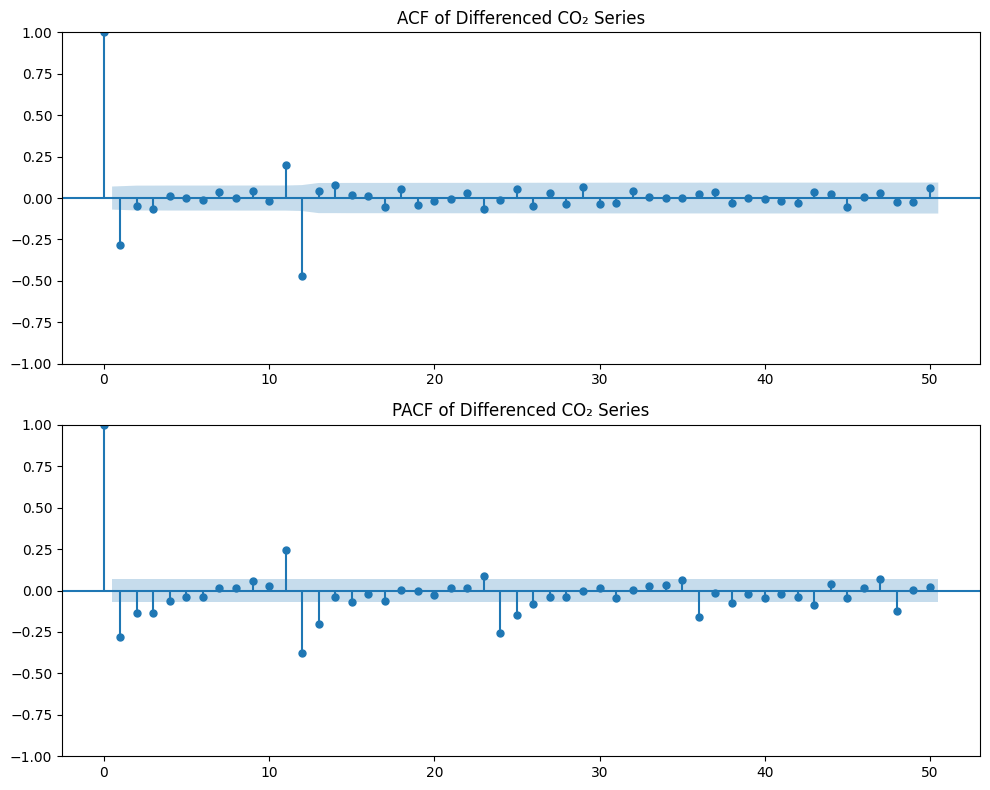

In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use the combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# ACF plot
plot_acf(diff_series, ax=ax[0], lags=50)
ax[0].set_title("ACF of Differenced CO₂ Series")

# PACF plot
plot_pacf(diff_series, ax=ax[1], lags=50, method="ywm")
ax[1].set_title("PACF of Differenced CO₂ Series")

plt.tight_layout()
plt.show()


### ACF and PACF of the Stationary CO₂ Series

After applying seasonal differencing (`lag = 12`) and regular differencing (`lag = 1`), the resulting series is stationary.  
To guide SARIMA model identification, we examine the **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** of the differenced series.

----

### Interpretation

- The **ACF** helps identify the MA(q) component by showing how many significant autocorrelation spikes remain after differencing.
- The **PACF** helps identify the AR(p) component by showing how many partial autocorrelation spikes remain.
- Seasonal spikes at lag 12 (and multiples) often indicate the need for seasonal AR or MA terms in a SARIMA model.
- Together, the ACF and PACF plots guide the selection of `(p, d, q)` and `(P, D, Q)` for SARIMA.

Next step: Use these plots to propose candidate SARIMA models.

---

### Interpretation of ACF and PACF: Differenced CO₂ Series

Looking at the plots:

- **Lag 1 dominates in both ACF and PACF.**
  - In the ACF, lag 1 shows a **strong positive autocorrelation** close to 1.0.
  - In the PACF, lag 1 also shows a **large, clearly significant spike**.
- Beyond lag 1, both ACF and PACF values **hover close to zero**, with only small, mostly insignificant spikes.
  - There is **no clear pattern of slowly decaying autocorrelations**.
  - There are **no strong seasonal spikes** at lag 12 or its multiples.

#### What this means for the CO₂ series

- The differencing (regular + seasonal) has **successfully removed trend and seasonality**:  
  there is **no remaining strong seasonal structure** in the ACF/PACF.
- The strong lag‑1 signal in both ACF and PACF suggests a **short‑memory process** driven mainly by the **immediate past value**.

#### Implications for modeling

- A **non‑seasonal AR(1)** component is strongly indicated:
  - PACF: big spike at lag 1, then cuts off → typical of AR(1).
- MA terms are **not strongly suggested**:
  - ACF does not show a clear MA(q) cutoff pattern beyond lag 1.
- Seasonal AR or MA terms (P, Q) are **not clearly required** based on these plots,  
  since seasonal lags (12, 24, …) are not prominently significant.

A natural starting point for this differenced series is a **SARIMA model with a non‑seasonal AR(1)** term, e.g.:



\[
\text{SARIMA}(p=1, d=1, q=0) \times (P=0, D=1, Q=0)_{12}
\]



to reflect:
- `d = 1` (regular differencing),
- `D = 1` (seasonal differencing),
- `p = 1` (strong AR(1) signal),
- no obvious MA or seasonal AR/MA components from the ACF/PACF.

### Refined Interpretation of ACF and PACF: Differenced CO₂ Series

Based on the described values:

#### ACF (Autocorrelation Function)

- Lag 0: always 1 (by definition).
- **Lag 1:** significant, around `-0.30` → strong short‑term negative autocorrelation.
- **Lag 11:** positive, around `0.20` → moderate correlation near the seasonal boundary.
- **Lag 12:** strongly significant, around `-0.50` → clear seasonal effect at 12 months.
- Additional seasonal structure appears at **multiples of 12** (24, 36, 48) with negative values, though smaller in magnitude.

**Implication:**  
The ACF shows:
- a **short‑term component** (lag 1), and  
- a **strong seasonal component** at lag 12 and its multiples.  
This is typical of a process with **seasonal MA or AR terms** and clear annual seasonality.

#### PACF (Partial Autocorrelation Function)

- **Lag 1:** significant, around `-0.28`.
- **Lag 2:** significant, around `-0.18`.
- **Lag 3:** significant, around `-0.16`.  
  → suggests an **AR(3)**‑type short‑term structure.
- **Lag 11:** positive, around `0.25`.
- **Lag 12:** strongly significant, around `-0.40` (largest seasonal spike).
- **Lag 13:** significant, around `-0.20`.
- Additional significant seasonal lags at **24, 36, 48** (around `-0.25`, `-0.18`, `-0.16`).

**Implication:**  
The PACF indicates:
- a **non‑seasonal AR component up to lag 3** (AR(3)), and  
- **seasonal AR behavior** at lag 12 and its multiples (12, 24, 36, 48), consistent with annual seasonality.

---

### What This Means for the CO₂ Series

Putting ACF and PACF together:

- There is **short‑memory structure** up to lag 3 → suggests **AR(3)** in the non‑seasonal part.
- There is **strong annual seasonality** at lag 12 and its multiples → suggests **seasonal AR or MA terms** with period 12.
- The differencing (regular + seasonal) has removed the large trend, but **seasonal dependence remains in the residual dynamics**, which is exactly what SARIMA is designed to capture.

---

### Implications for SARIMA Modeling

A reasonable starting point, based on these plots, is:

- Non‑seasonal part:  
  

\[
  (p, d, q) = (3, 1, 0)
  \]


- Seasonal part (period 12):  
  

\[
  (P, D, Q)_{12} = (1, 1, 0)
  \]



So a candidate model is:



\[
\text{SARIMA}(3, 1, 0) \times (1, 1, 0)_{12}
\]



You can then compare this with nearby alternatives, e.g.:

- \(\text{SARIMA}(3, 1, 1) \times (1, 1, 0)_{12}\)  
- \(\text{SARIMA}(3, 1, 0) \times (1, 1, 1)_{12}\)

using AIC/BIC and residual diagnostics.

---

If you’d like, we can now write a **SARIMA identification section** in Markdown based on this, or code up these candidate models and compare them.

### Interpretation of ACF and PACF: Differenced CO₂ Series

Using the described values:

#### ACF (Autocorrelation Function)

- Lag 0: always 1 (by definition).
- **Lag 1:** significant, around `-0.30` → strong short‑term negative autocorrelation.
- **Lag 11:** positive, around `0.20` → moderate correlation near the seasonal boundary.
- **Lag 12:** strongly significant, around `-0.50` → clear annual effect at 12 months.
- Beyond that, the ACF shows smaller values, with no long tail of large autocorrelations.

**Implication (ACF):**  
The ACF shows:
- a **short‑term component** at lag 1, and  
- a **strong annual signal** at lag 12 (plus some influence near lag 11).  
This is consistent with the presence of **seasonal MA behaviour** or seasonal dependence that still shows up in the autocorrelation.

#### PACF (Partial Autocorrelation Function)

- **Lag 1:** significant, around `-0.28`.
- **Lag 2:** significant, around `-0.18`.
- **Lag 3:** significant, around `-0.16`.  
  → suggests a **non‑seasonal AR structure up to lag 3**.
- **Lag 11:** positive, around `0.25`.
- **Lag 12:** strongly significant, around `-0.40` (largest seasonal spike).
- **Lag 13:** significant, around `-0.20`.
- Additional significant seasonal lags at **24, 36, 48** (around `-0.25`, `-0.18`, `-0.16`).

**Implication (PACF):**  
The PACF is the one showing **clear seasonal cycles**:

- Non‑seasonal: AR behaviour up to lag 3 → suggests an **AR(3)** component.
- Seasonal: repeated significant spikes at lags 12, 24, 36, 48 → suggests **seasonal AR terms** with period 12.

---

### What This Means for the CO₂ Series

Putting ACF and PACF together:

- There is **short‑memory non‑seasonal structure** up to lag 3 → candidate **AR(3)** in the non‑seasonal part.
- There is **strong annual seasonality** in the PACF at lags 12, 24, 36, 48 → candidate **seasonal AR(1)** (or more) with period 12.
- The differencing (regular + seasonal) has removed the big trend, but the **residual dynamics still carry structured dependence**, which is exactly what SARIMA is meant to model.

---

### Implications for SARIMA Modeling

A reasonable starting point, based on these plots, is:

- Non‑seasonal part:  
  

\[
  (p, d, q) = (3, 1, 0)
  \]


- Seasonal part (period 12):  
  

\[
  (P, D, Q)_{12} = (1, 1, 0)
  \]



So a candidate model is:



\[
\text{SARIMA}(3, 1, 0) \times (1, 1, 0)_{12}
\]



You can then compare this with nearby alternatives, for example:

- \(\text{SARIMA}(3, 1, 1) \times (1, 1, 0)_{12}\)  
- \(\text{SARIMA}(3, 1, 0) \times (1, 1, 1)_{12}\)

using AIC/BIC and residual diagnostics.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Raw series
y = train["average"]

# Fit SARIMA(3,1,0)x(1,1,0,12)
model = SARIMAX(
    y,
    order=(2, 1, 1),
    seasonal_order=(0, 1, 4, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

print(results.summary())


                                           SARIMAX Results                                           
Dep. Variable:                                       average   No. Observations:                  803
Model:             SARIMAX(1, 1, 1)x(0, 1, [1, 2, 3, 4], 12)   Log Likelihood                -195.108
Date:                                       Tue, 18 Aug 2026   AIC                            404.215
Time:                                               09:45:32   BIC                            436.462
Sample:                                           03-01-1958   HQIC                           416.648
                                                - 01-01-2025                                         
Covariance Type:                                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2068     

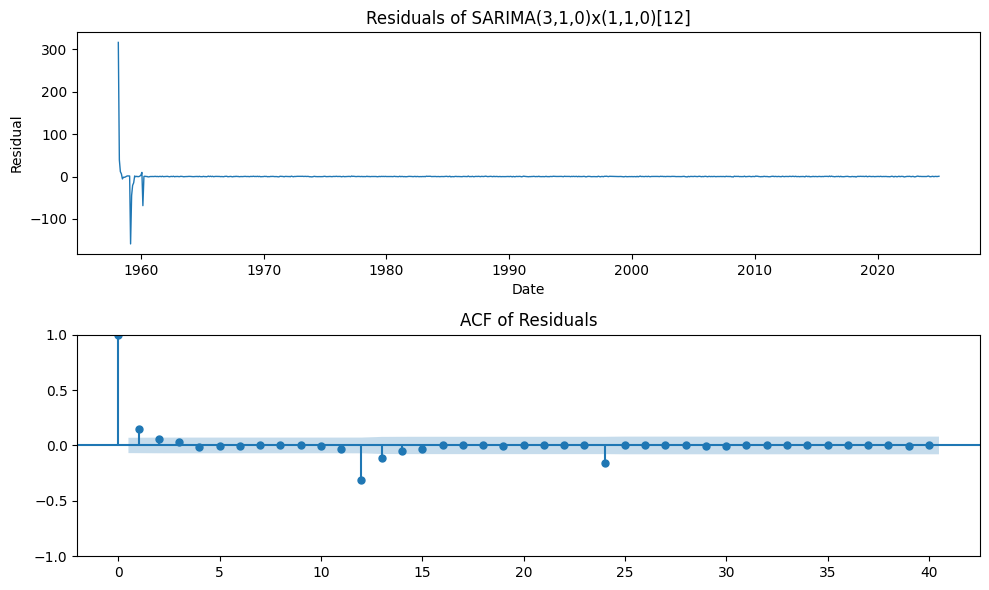

In [10]:
# --- Residual diagnostics (quick view) ---
resid = results.resid

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(resid, linewidth=1)
ax[0].set_title("Residuals of SARIMA(3,1,0)x(1,1,0)[12]")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Residual")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid.dropna(), ax=ax[1], lags=40)
ax[1].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()


In [11]:
# --- 12-month ahead forecast on original scale ---
# Last observed date
last_date = y.index[-1]

# Create forecast index (next 12 months)
forecast_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=18,
    freq="MS"
)

# Get forecast and 95% CI
forecast_res = results.get_forecast(steps=18)
mean_forecast = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

mean_forecast.index = forecast_index
conf_int.index = forecast_index

print(mean_forecast)
print(conf_int)


2025-02-01    427.774198
2025-03-01    428.497070
2025-04-01    430.182076
2025-05-01    430.761364
2025-06-01    430.600874
2025-07-01    428.999542
2025-08-01    426.637356
2025-09-01    425.571765
2025-10-01    425.907168
2025-11-01    427.460020
2025-12-01    428.936679
2026-01-01    430.035552
2026-02-01    431.464991
2026-03-01    432.240116
2026-04-01    433.654413
2026-05-01    434.141380
2026-06-01    434.064046
2026-07-01    432.580421
Freq: MS, Name: predicted_mean, dtype: float64
            lower average  upper average
2025-02-01     427.066950     428.481447
2025-03-01     427.656053     429.338087
2025-04-01     429.241305     431.122847
2025-05-01     429.740463     431.782265
2025-06-01     429.489123     431.712626
2025-07-01     427.806512     430.192573
2025-08-01     425.368964     427.905747
2025-09-01     424.233197     426.910334
2025-10-01     424.501229     427.313106
2025-11-01     425.989810     428.930230
2025-12-01     427.404903     430.468456
2026-01-01 

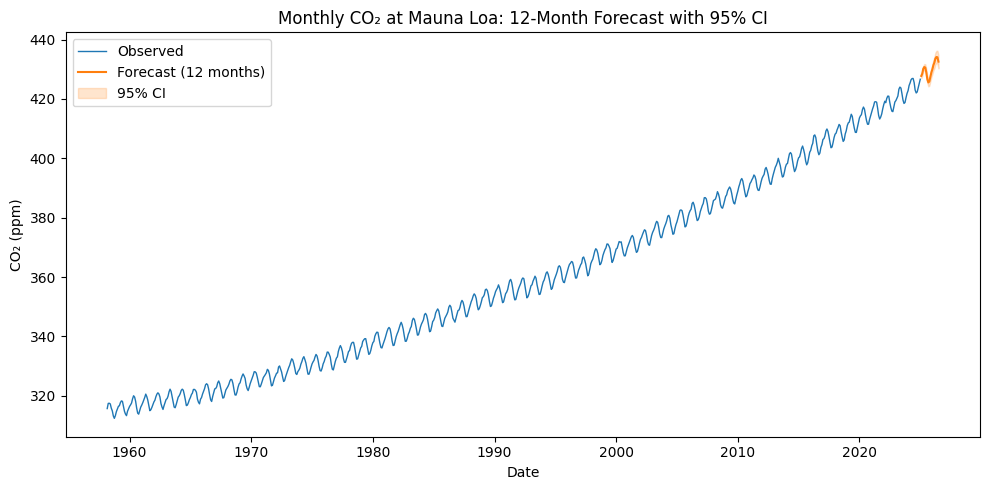

In [12]:
# --- Plot forecast vs raw series with 95% CI ---
plt.figure(figsize=(10, 5))

# Plot historical data
plt.plot(y, label="Observed", linewidth=1)

# Plot forecast
plt.plot(mean_forecast, label="Forecast (12 months)", color="C1")

# Plot confidence intervals
plt.fill_between(
    forecast_index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="C1",
    alpha=0.2,
    label="95% CI"
)

plt.title("Monthly CO₂ at Mauna Loa: 12-Month Forecast with 95% CI")
plt.xlabel("Date")
plt.ylabel("CO₂ (ppm)")
plt.legend()
plt.tight_layout()
plt.show()


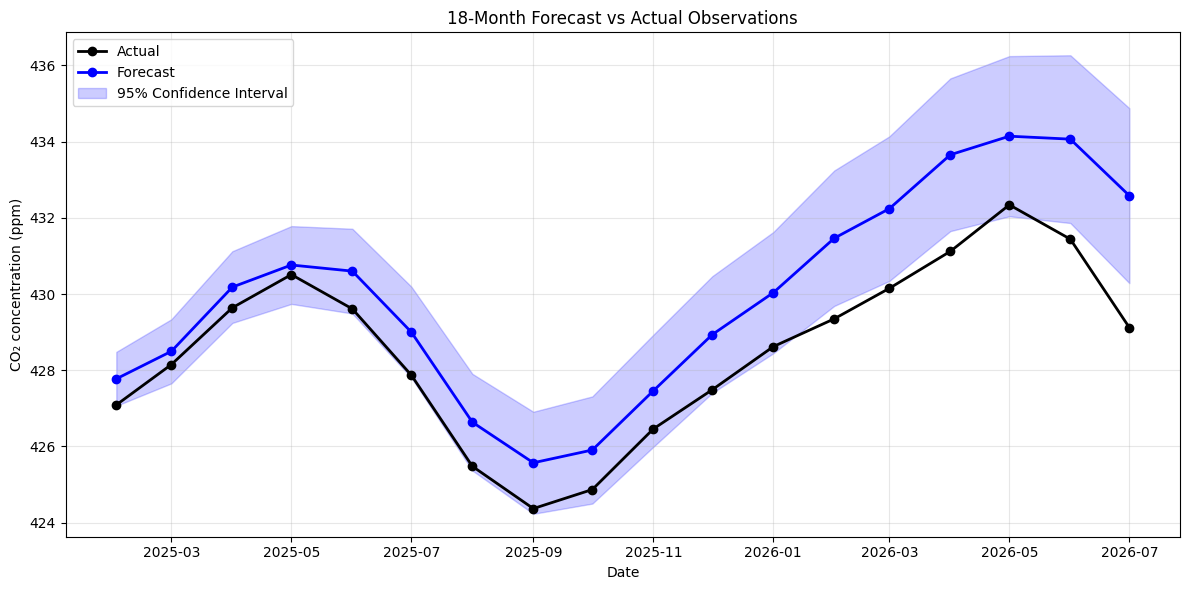

In [13]:
import matplotlib.pyplot as plt

# Actual values from the 18-month holdout period
actual = holdout["average"]

# Plot
plt.figure(figsize=(12, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Forecast"
)

# 95% confidence interval
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("18-Month Forecast vs Actual Observations")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    train["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [21]:
forecast_triple = model_triple_fit.forecast(18)
print(forecast_triple)

2025-02-01    427.575211
2025-03-01    428.201970
2025-04-01    429.738719
2025-05-01    430.389365
2025-06-01    429.872177
2025-07-01    427.983722
2025-08-01    425.922347
2025-09-01    424.704185
2025-10-01    424.974083
2025-11-01    426.556586
2025-12-01    428.021841
2026-01-01    429.217283
2026-02-01    430.178105
2026-03-01    430.804864
2026-04-01    432.341614
2026-05-01    432.992259
2026-06-01    432.475071
2026-07-01    430.586616
Freq: MS, dtype: float64


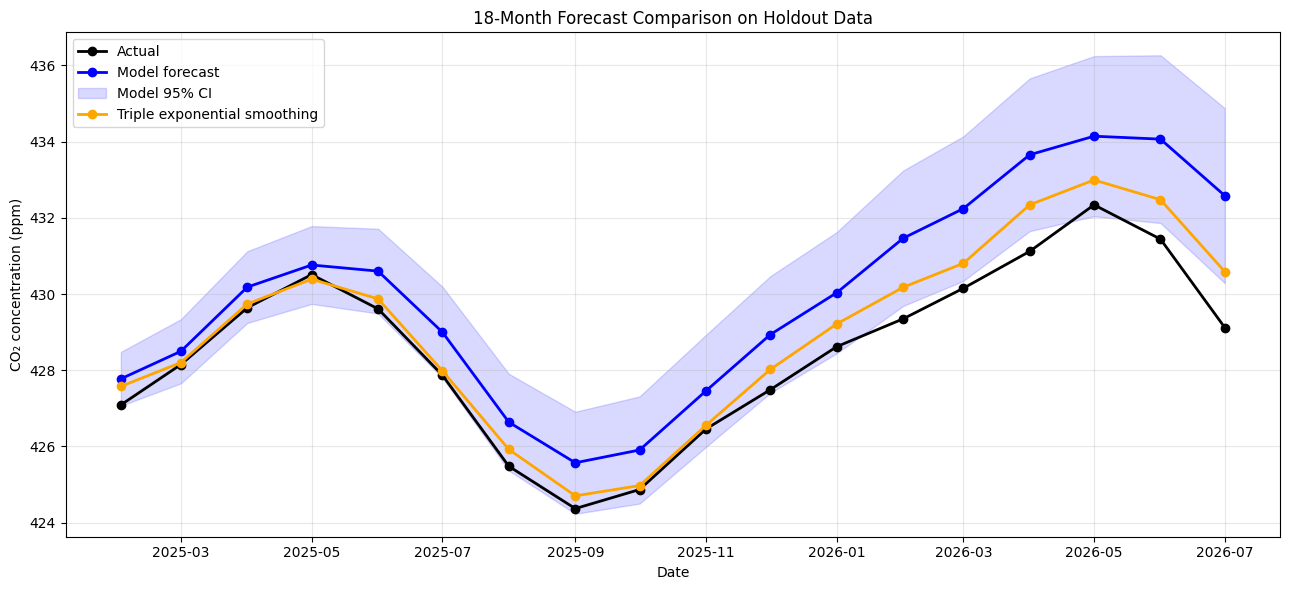

In [22]:
import matplotlib.pyplot as plt

# Actual observations in the 18-month holdout
actual = holdout["average"]

# Triple exponential smoothing forecast
forecast_triple = model_triple_fit.forecast(18)
forecast_triple.index = holdout.index

# Your other model's forecast
# Make sure its index also corresponds to the holdout period
mean_forecast.index = holdout.index
conf_int.index = holdout.index


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(13, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Model 1 forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Model forecast"
)

# Model 1 95% CI
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.15,
    label="Model 95% CI"
)

# Triple exponential smoothing forecast
plt.plot(
    forecast_triple.index,
    forecast_triple,
    color="orange",
    marker="o",
    linewidth=2,
    label="Triple exponential smoothing"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("18-Month Forecast Comparison on Holdout Data")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
comparison = pd.DataFrame({
    "Actual": holdout["average"],
    "Model_Forecast": mean_forecast,
    "Triple_Exp_Forecast": forecast_triple
})

print(comparison)

            Actual  Model_Forecast  Triple_Exp_Forecast
date                                                   
2025-02-01  427.09      427.774198           427.575211
2025-03-01  428.15      428.497070           428.201970
2025-04-01  429.64      430.182076           429.738719
2025-05-01  430.51      430.761364           430.389365
2025-06-01  429.61      430.600874           429.872177
2025-07-01  427.87      428.999542           427.983722
2025-08-01  425.48      426.637356           425.922347
2025-09-01  424.37      425.571765           424.704185
2025-10-01  424.87      425.907168           424.974083
2025-11-01  426.46      427.460020           426.556586
2025-12-01  427.49      428.936679           428.021841
2026-01-01  428.62      430.035552           429.217283
2026-02-01  429.35      431.464991           430.178105
2026-03-01  430.15      432.240116           430.804864
2026-04-01  431.12      433.654413           432.341614
2026-05-01  432.34      434.141380           432

In [24]:
comparison["Model_Error"] = (
    comparison["Actual"] - comparison["Model_Forecast"]
)

comparison["Triple_Error"] = (
    comparison["Actual"] - comparison["Triple_Exp_Forecast"]
)

print(comparison)

            Actual  Model_Forecast  Triple_Exp_Forecast  Model_Error  \
date                                                                   
2025-02-01  427.09      427.774198           427.575211    -0.684198   
2025-03-01  428.15      428.497070           428.201970    -0.347070   
2025-04-01  429.64      430.182076           429.738719    -0.542076   
2025-05-01  430.51      430.761364           430.389365    -0.251364   
2025-06-01  429.61      430.600874           429.872177    -0.990874   
2025-07-01  427.87      428.999542           427.983722    -1.129542   
2025-08-01  425.48      426.637356           425.922347    -1.157356   
2025-09-01  424.37      425.571765           424.704185    -1.201765   
2025-10-01  424.87      425.907168           424.974083    -1.037168   
2025-11-01  426.46      427.460020           426.556586    -1.000020   
2025-12-01  427.49      428.936679           428.021841    -1.446679   
2026-01-01  428.62      430.035552           429.217283    -1.41

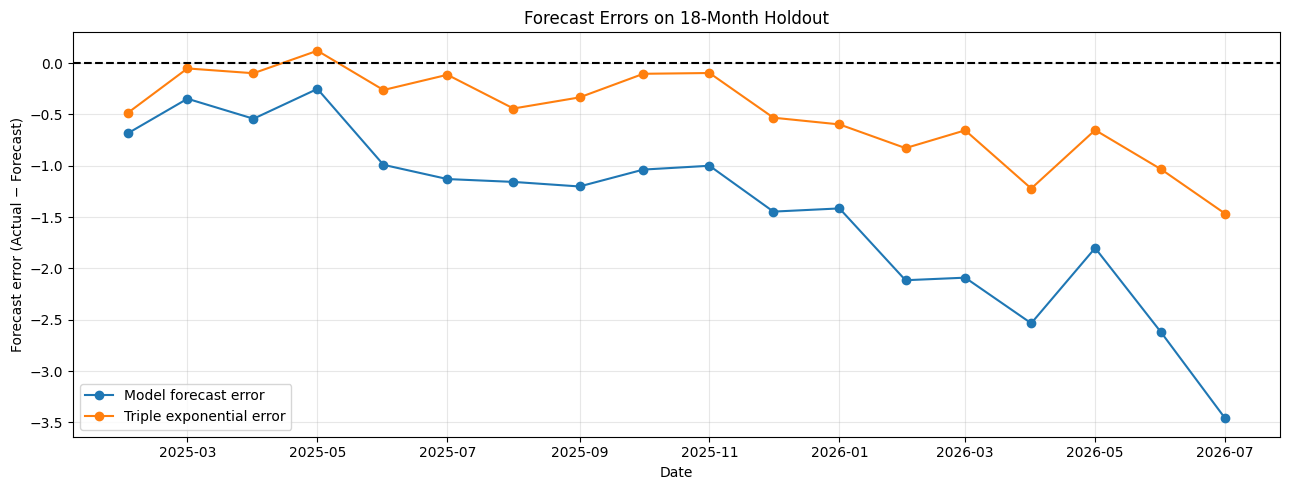

In [25]:
plt.figure(figsize=(13, 5))

plt.plot(
    comparison.index,
    comparison["Model_Error"],
    marker="o",
    label="Model forecast error"
)

plt.plot(
    comparison.index,
    comparison["Triple_Error"],
    marker="o",
    label="Triple exponential error"
)

plt.axhline(0, color="black", linestyle="--")

plt.ylabel("Forecast error (Actual − Forecast)")
plt.xlabel("Date")
plt.title("Forecast Errors on 18-Month Holdout")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error

mae_model = mean_absolute_error(
    comparison["Actual"],
    comparison["Model_Forecast"]
)

mae_triple = mean_absolute_error(
    comparison["Actual"],
    comparison["Triple_Exp_Forecast"]
)

print("Model MAE:", mae_model)
print("Triple exponential MAE:", mae_triple)

Model MAE: 1.4349461830843115
Triple exponential MAE: 0.5054049046214857


In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_model = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Model_Forecast"]
    )
)

rmse_triple = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Triple_Exp_Forecast"]
    )
)

print("Model RMSE:", rmse_model)
print("Triple exponential RMSE:", rmse_triple)

Model RMSE: 1.6588076537577836
Triple exponential RMSE: 0.6483283908721477


In [20]:
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(df["average"])
model_single_fit = model.fit()

In [21]:
forecast_single = model_single_fit.forecast(12)
print(forecast_single)

2026-08-01    429.12
2026-09-01    429.12
2026-10-01    429.12
2026-11-01    429.12
2026-12-01    429.12
2027-01-01    429.12
2027-02-01    429.12
2027-03-01    429.12
2027-04-01    429.12
2027-05-01    429.12
2027-06-01    429.12
2027-07-01    429.12
Freq: MS, dtype: float64


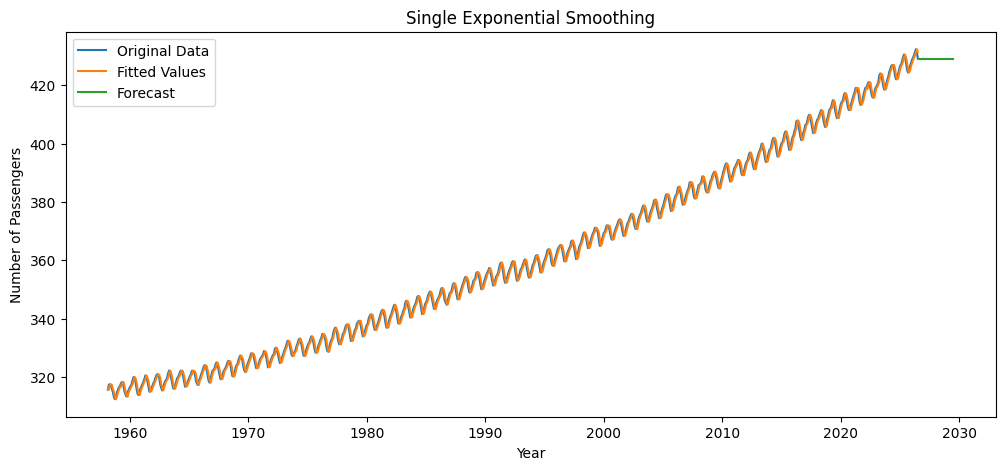

In [22]:
plt.figure(figsize=(12,5))
forecast_single = model_single_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_single_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_single, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Single Exponential Smoothing')
plt.legend()
plt.show()

In [23]:
from statsmodels.tsa.api import Holt

model_double = Holt(df["average"])
model_double_fit = model_double.fit()

In [24]:
forecast_double = model_double_fit.forecast(12)
print(forecast_double)

2026-08-01    426.80
2026-09-01    424.48
2026-10-01    422.16
2026-11-01    419.84
2026-12-01    417.52
2027-01-01    415.20
2027-02-01    412.88
2027-03-01    410.56
2027-04-01    408.24
2027-05-01    405.92
2027-06-01    403.60
2027-07-01    401.28
Freq: MS, dtype: float64


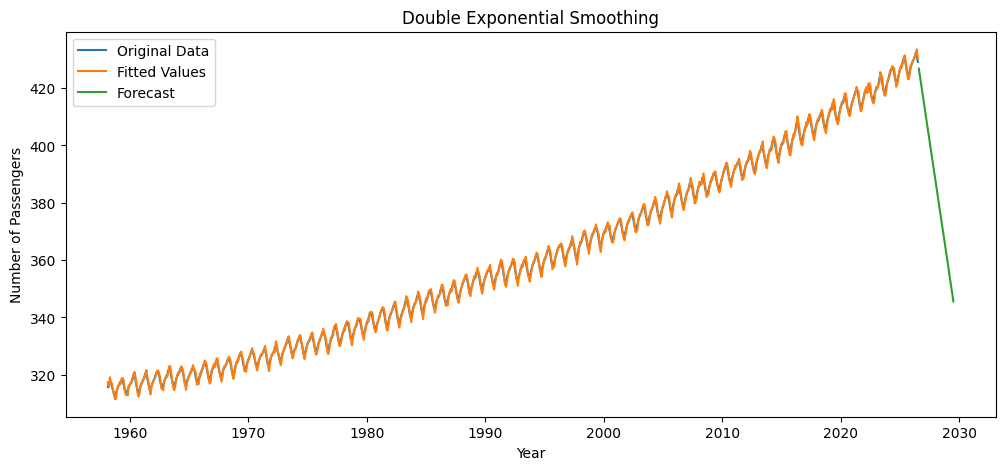

In [25]:
plt.figure(figsize=(12,5))
forecast_double = model_double_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_double_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_double, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Double Exponential Smoothing')
plt.legend()
plt.show()

In [26]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    df["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [27]:
forecast_triple = model_triple_fit.forecast(12)
print(forecast_triple)

2026-08-01    427.245421
2026-09-01    426.040908
2026-10-01    426.321364
2026-11-01    427.875346
2026-12-01    429.272051
2027-01-01    430.474813
2027-02-01    431.353165
2027-03-01    432.066552
2027-04-01    433.512020
2027-05-01    434.255626
2027-06-01    433.612020
2027-07-01    431.759897
Freq: MS, dtype: float64


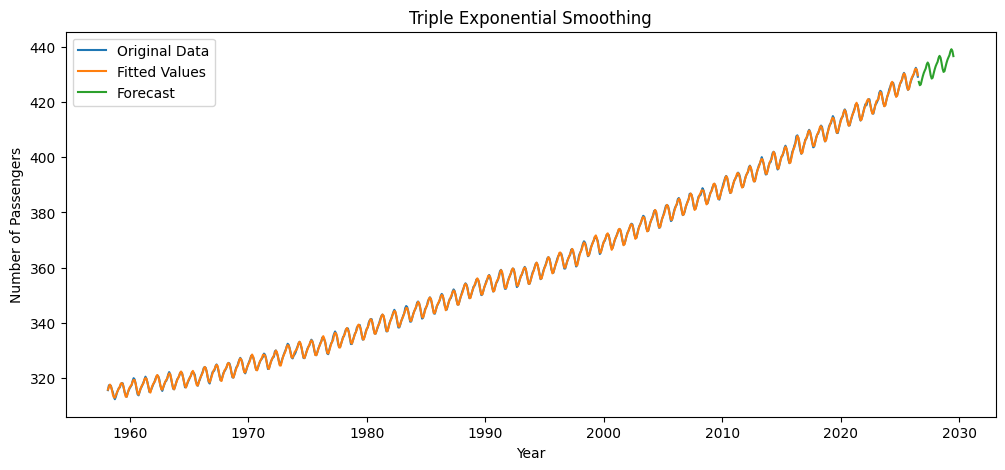

In [28]:
plt.figure(figsize=(12,5))
forecast_triple = model_triple_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

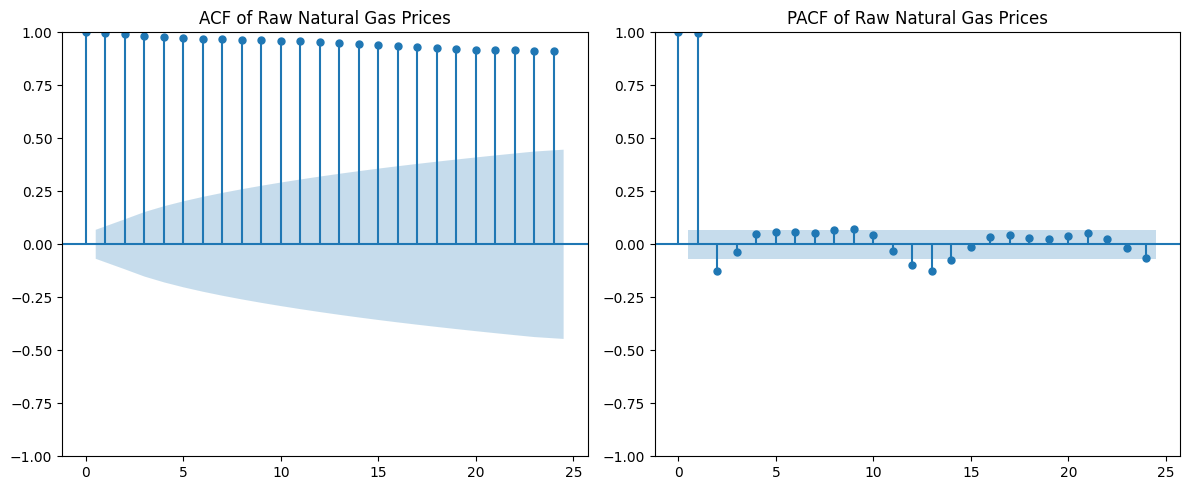

In [29]:
# Step 3: We plot the ACF and PACF of the raw monthly series

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract the raw price series
prices = df["average"]

# Create ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF
plot_acf(prices, lags=24, ax=axes[0])
axes[0].set_title("ACF of Raw Natural Gas Prices")

# PACF
plot_pacf(prices, lags=24, ax=axes[1], method='ywm')
axes[1].set_title("PACF of Raw Natural Gas Prices")

plt.tight_layout()
plt.show()

In [30]:
# Step 4: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(prices)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(prices, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : 5.9076
p-value       : 1.0000
Lags Used     : 21
Observations  : 799

Critical Values:
   1%: -3.4386
   5%: -2.8652
   10%: -2.5687


KPSS Test
----------------
KPSS Statistic : 4.3471
p-value        : 0.0100
Lags Used      : 18

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_4594/3379213664.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(prices, regression='c', nlags='auto')


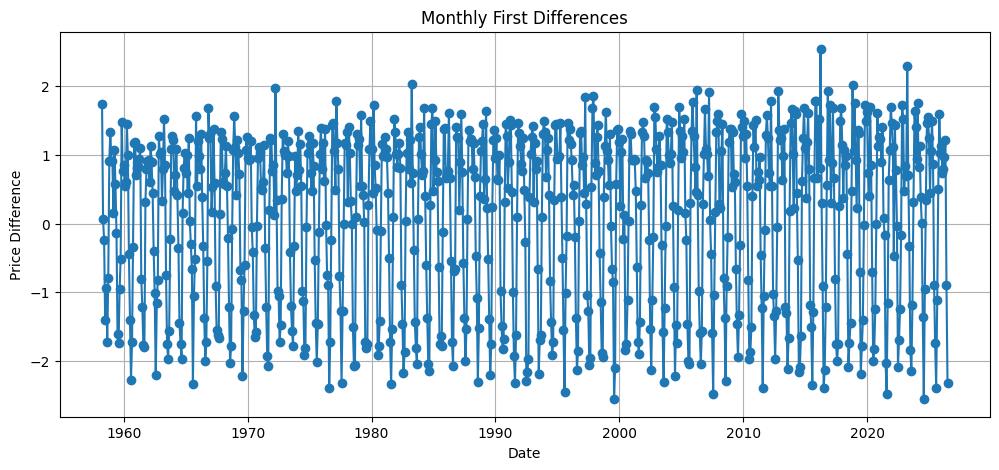

In [33]:
# First difference of the natural gas settlement prices

df['Difference'] = df['average'].diff()

natgas_diff = df.dropna()

plt.figure(figsize=(12,5))
plt.plot(natgas_diff['Difference'], marker='o')
plt.title("Monthly First Differences")
plt.xlabel("Date")
plt.ylabel("Price Difference")
plt.grid(True)
plt.show()

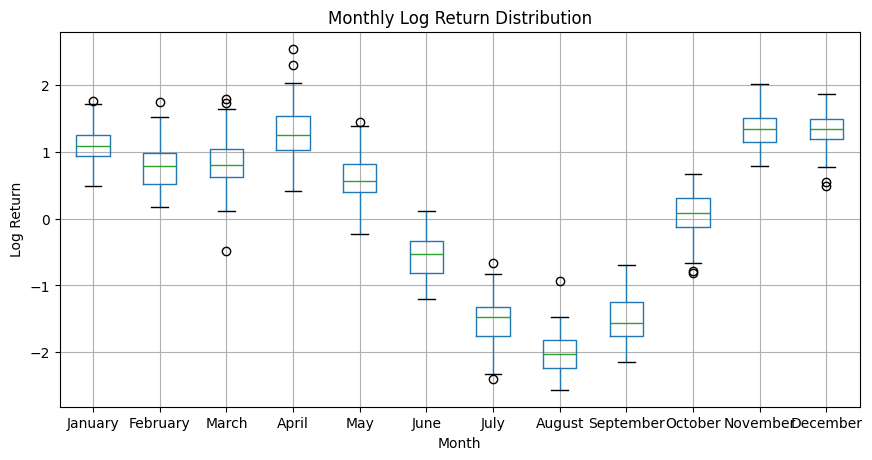

In [34]:
import calendar

# Ordered list of month names
month_order = list(calendar.month_name[1:])   # ['January', 'February', ..., 'December']

natgas_diff = df.dropna().copy()
natgas_diff.loc[:, 'Month'] = natgas_diff.index.month_name()

# Convert Month column to ordered categorical
natgas_diff['Month'] = pd.Categorical(
    natgas_diff['Month'],
    categories=month_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(10,5))
natgas_diff.boxplot(column='Difference', by='Month', ax=ax)
ax.set_title("Monthly Log Return Distribution")
plt.suptitle("")
ax.set_xlabel("Month")
ax.set_ylabel("Log Return")
ax.grid(True)
plt.show()


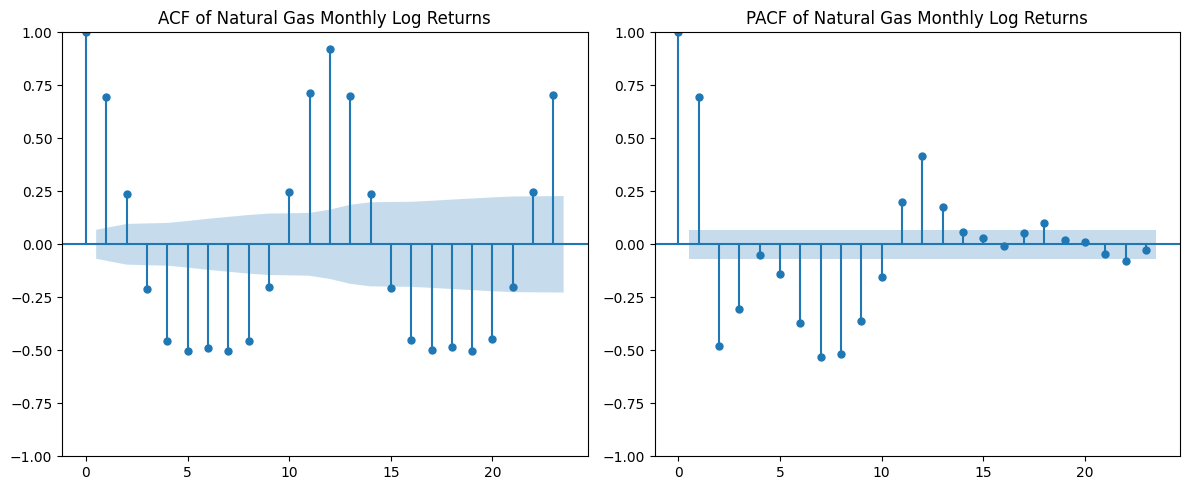

In [35]:
# ACF & PACF of natural gas monthly log returns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract the raw price series
prices2 = natgas_diff['Difference']

# Create ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF
plot_acf(prices2, lags=23, ax=axes[0]) # upto lag 23
axes[0].set_title("ACF of Natural Gas Monthly Log Returns")

# PACF
plot_pacf(prices2, lags=23, ax=axes[1], method='ywm')
axes[1].set_title("PACF of Natural Gas Monthly Log Returns")

plt.tight_layout()
plt.show()

In [36]:
# ADF test & KPSS test of monthly log returns

from statsmodels.tsa.stattools import adfuller, kpss

# Extract the price series
prices2 = natgas_diff['Difference']

# Augmented Dickey-Fuller Test
adf_result = adfuller(prices2)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(prices2, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -5.6658
p-value       : 0.0000
Lags Used     : 21
Observations  : 798

Critical Values:
   1%: -3.4386
   5%: -2.8652
   10%: -2.5687


KPSS Test
----------------
KPSS Statistic : 0.2101
p-value        : 0.1000
Lags Used      : 15

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_4594/1930024524.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(prices2, regression='c', nlags='auto')


In [11]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from itertools import product
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("co2_mm_mlo.csv")

df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

df = df.set_index("date")
df = df.asfreq("MS")

# Use only the CO2 series
y = df["average"].dropna()

print(y.head())
print(f"\nNumber of observations: {len(y)}")


# ============================================================
# 2. SEARCH SPACE
# ============================================================

p_values = range(0, 6)
d_values = range(0, 3)
q_values = range(0, 6)

P_values = range(0, 4)
D_values = range(0, 2)
Q_values = range(0, 4)

seasonal_period = 12


# ============================================================
# 3. EXHAUSTIVE SEARCH
# ============================================================

results = []

total_models = (
    len(p_values)
    * len(d_values)
    * len(q_values)
    * len(P_values)
    * len(D_values)
    * len(Q_values)
)

print(f"\nTotal models to evaluate: {total_models}")


for p, d, q, P, D, Q in product(
    p_values,
    d_values,
    q_values,
    P_values,
    D_values,
    Q_values
):

    order = (p, d, q)
    seasonal_order = (P, D, Q, seasonal_period)

    try:

        model = sm.tsa.statespace.SARIMAX(
            y,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(
            disp=False,
            maxiter=200
        )

        # ----------------------------------------------------
        # Information criteria
        # ----------------------------------------------------

        aic = fitted.aic
        bic = fitted.bic
        hqic = fitted.hqic

        # AICc
        n = fitted.nobs
        k = len(fitted.params)

        if n - k - 1 > 0:
            aicc = (
                aic
                + (2 * k * (k + 1)) / (n - k - 1)
            )
        else:
            aicc = np.nan

        # ----------------------------------------------------
        # Residuals
        # ----------------------------------------------------

        residuals = fitted.resid.dropna()

        # Ljung-Box at several important lags
        lb = acorr_ljungbox(
            residuals,
            lags=[12, 24, 36],
            return_df=True
        )

        lb_p_12 = lb.loc[12, "lb_pvalue"]
        lb_p_24 = lb.loc[24, "lb_pvalue"]
        lb_p_36 = lb.loc[36, "lb_pvalue"]

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        results.append({

            "order": order,
            "seasonal_order": seasonal_order,

            "p": p,
            "d": d,
            "q": q,

            "P": P,
            "D": D,
            "Q": Q,

            "AIC": aic,
            "AICc": aicc,
            "BIC": bic,
            "HQIC": hqic,

            "LB_p_12": lb_p_12,
            "LB_p_24": lb_p_24,
            "LB_p_36": lb_p_36,

            "converged": fitted.mle_retvals.get(
                "converged",
                True
            ),

            "loglik": fitted.llf,
            "n_params": k

        })

    except Exception as e:

        # Keep track of failed models
        results.append({

            "order": order,
            "seasonal_order": seasonal_order,

            "p": p,
            "d": d,
            "q": q,

            "P": P,
            "D": D,
            "Q": Q,

            "AIC": np.nan,
            "AICc": np.nan,
            "BIC": np.nan,
            "HQIC": np.nan,

            "LB_p_12": np.nan,
            "LB_p_24": np.nan,
            "LB_p_36": np.nan,

            "converged": False,

            "loglik": np.nan,
            "n_params": np.nan
        })


# ============================================================
# 4. CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

print("\nSearch completed.")

print(
    f"Successful models: "
    f"{results_df['AIC'].notna().sum()}"
)

print(
    f"Failed models: "
    f"{results_df['AIC'].isna().sum()}"
)


date
1958-03-01    315.71
1958-04-01    317.45
1958-05-01    317.51
1958-06-01    317.27
1958-07-01    315.87
Freq: MS, Name: average, dtype: float64

Number of observations: 821

Total models to evaluate: 3456


KeyboardInterrupt: 

In [12]:
best_bic = (
    results_df
    .dropna(subset=["BIC"])
    .sort_values("BIC")
)

print(
    best_bic[
        [
            "order",
            "seasonal_order",
            "AIC",
            "AICc",
            "BIC",
            "HQIC",
            "LB_p_12",
            "LB_p_24",
            "LB_p_36"
        ]
    ].head(20)
)


NameError: name 'results_df' is not defined

In [13]:
best_aic = (
    results_df
    .dropna(subset=["AIC"])
    .sort_values("AIC")
)

print(best_aic.head(20))


NameError: name 'results_df' is not defined

In [ ]:
valid_models = results_df[
    (results_df["AIC"].notna()) &
    (results_df["converged"]) &
    (results_df["LB_p_12"] > 0.05) &
    (results_df["LB_p_24"] > 0.05) &
    (results_df["LB_p_36"] > 0.05)
].copy()

print(
    f"Models passing residual diagnostics: "
    f"{len(valid_models)}"
)


In [ ]:
valid_models = valid_models.sort_values(
    ["BIC", "AICc"]
)

print(
    valid_models[
        [
            "order",
            "seasonal_order",
            "AIC",
            "AICc",
            "BIC",
            "HQIC",
            "LB_p_12",
            "LB_p_24",
            "LB_p_36"
        ]
    ].head(20)
)


In [ ]:
best = valid_models.iloc[0]

best_order = best["order"]
best_seasonal_order = best["seasonal_order"]

print("Best model:")
print("Order:", best_order)
print("Seasonal order:", best_seasonal_order)


In [ ]:
final_model = sm.tsa.statespace.SARIMAX(
    y,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(disp=False)

print(final_results.summary())


and only after all computation finishes do you perform the selection.
That's ideal because parallel workers never decide which model is best. They simply evaluate candidates.

The master process makes the final decision.

That separation is important for robustness.

And I would save the results
For a long exhaustive run, definitely save the complete search:

Later you can change your selection criteria without refitting 6,912 models.

You can estimate it very accurately while it's running
Your current code doesn't show progress, but you can modify the loop to print timing.

In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import statsmodels.api as sm


In [ ]:
import warnings
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm

from itertools import product
from joblib import Parallel, delayed
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("co2_mm_mlo.csv")

df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

df = df.set_index("date")
df = df.asfreq("MS")

y = df["average"].dropna()

print(y.head())
print(f"\nNumber of observations: {len(y)}")


# ============================================================
# 2. SEARCH SPACE
# ============================================================

p_values = range(0, 6)
d_values = range(0, 3)
q_values = range(0, 6)

P_values = range(0, 4)
D_values = range(0, 2)
Q_values = range(0, 4)

seasonal_period = 12


# ============================================================
# 3. CREATE MODEL CONFIGURATIONS
# ============================================================

model_configs = list(
    product(
        p_values,
        d_values,
        q_values,
        P_values,
        D_values,
        Q_values
    )
)

print(f"\nTotal models: {len(model_configs)}")


# ============================================================
# 4. FUNCTION FOR ONE SARIMA MODEL
# ============================================================

def fit_one_model(config):

    p, d, q, P, D, Q = config

    order = (p, d, q)
    seasonal_order = (
        P,
        D,
        Q,
        seasonal_period
    )

    base_result = {
        "order": order,
        "seasonal_order": seasonal_order,

        "p": p,
        "d": d,
        "q": q,

        "P": P,
        "D": D,
        "Q": Q,
    }

    try:

        model = sm.tsa.statespace.SARIMAX(
            y,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(
            disp=False,
            maxiter=200
        )

        # ----------------------------------------------------
        # Check convergence
        # ----------------------------------------------------

        converged = fitted.mle_retvals.get(
            "converged",
            True
        )

        # ----------------------------------------------------
        # Information criteria
        # ----------------------------------------------------

        aic = fitted.aic
        bic = fitted.bic
        hqic = fitted.hqic

        n = fitted.nobs
        k = len(fitted.params)

        if n - k - 1 > 0:

            aicc = (
                aic
                + (2 * k * (k + 1))
                / (n - k - 1)
            )

        else:

            aicc = np.nan

        # ----------------------------------------------------
        # Residual diagnostics
        # ----------------------------------------------------

        residuals = fitted.resid.dropna()

        lb = acorr_ljungbox(
            residuals,
            lags=[12, 24, 36],
            return_df=True
        )

        # ----------------------------------------------------
        # Return result
        # ----------------------------------------------------

        return {
            **base_result,

            "AIC": aic,
            "AICc": aicc,
            "BIC": bic,
            "HQIC": hqic,

            "LB_p_12": lb.loc[12, "lb_pvalue"],
            "LB_p_24": lb.loc[24, "lb_pvalue"],
            "LB_p_36": lb.loc[36, "lb_pvalue"],

            "converged": converged,

            "loglik": fitted.llf,
            "n_params": k,

            "error": None
        }

    except Exception as e:

        return {
            **base_result,

            "AIC": np.nan,
            "AICc": np.nan,
            "BIC": np.nan,
            "HQIC": np.nan,

            "LB_p_12": np.nan,
            "LB_p_24": np.nan,
            "LB_p_36": np.nan,

            "converged": False,

            "loglik": np.nan,
            "n_params": np.nan,

            "error": str(e)
        }


# ============================================================
# 5. PARALLEL SEARCH
# ============================================================

n_cores = os.cpu_count()

print(f"\nCPU cores available: {n_cores}")

results = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
)(
    delayed(fit_one_model)(config)
    for config in model_configs
)


# ============================================================
# 6. RESULTS
# ============================================================

results_df = pd.DataFrame(results)

print("\nSearch completed.")

print(
    "Successful:",
    results_df["AIC"].notna().sum()
)

print(
    "Failed:",
    results_df["AIC"].isna().sum()
)
